In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
import ast
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.patches as patches

In [2]:
DATA_DIR = os.path.expanduser("data/fingernail-anemia")
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")

In [185]:
def load_and_describe_metadata(csv_path='metadata.csv'):
    """
    Loads metadata and prints basic descriptive statistics.
    """
    df = pd.read_csv(csv_path)
    n=30
    df["HB_LEVEL_GperDeciL"] = df["HB_LEVEL_GperL"]/10

    print(f"Random sample (n={n}) of metadata")
    display(df.sample(n))

    print("\nDescriptive Statistics:")
    display(df.describe())

    return df  # Return dataframe for further use

def plot_hb_distribution(df, hb_column='HB_LEVEL_GperDeciL'):
    """
    Plots the frequency distribution of hemoglobin levels.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(df[hb_column].dropna(), bins=30, color="blue", alpha=0.6)
    plt.title('Hemoglobin Level Distribution', {'fontsize':16})
    plt.xlabel('Hemoglobin Level (g/dL)', {'fontsize':12})
    plt.ylabel('Frequency', {'fontsize':12})
    plt.tight_layout()
    plt.show()

def load_images_from_directory(data_dir, resize=None):
    """
    Load all images from subdirectories in data_dir (e.g., Anemic, Non-anemic)
    """
    image_data = []
    labels = []

    for label in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    if resize:
                        img = cv2.resize(img, resize)
                    image_data.append(img)
                    labels.append(label)
            except Exception as e:
                print(f"Failed to load {img_path}: {e}")

    return np.array(image_data), labels

def plot_rgb_channel_distributions(images, label='All Images'):
    """
    Plot normalized histograms for each RGB channel
    """
    if len(images) == 0:
        print("No images to plot.")
        return

    r_vals, g_vals, b_vals = [], [], []
    for img in images:
        b, g, r = cv2.split(img)
        r_vals.extend(r.flatten())
        g_vals.extend(g.flatten())
        b_vals.extend(b.flatten())

    # Normalize histograms
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].hist(r_vals, bins=50, color='red', density=True)
    axs[0].set_title(f'Intensity in R Channel ({label})', {'fontsize':16})
    
    axs[1].hist(g_vals, bins=50, color='green', density=True)
    axs[1].set_title(f'Intensity in G Channel ({label})', {'fontsize':16})

    axs[2].hist(b_vals, bins=50, color='blue', density=True)
    axs[2].set_title(f'Intensity in B Channel ({label})', {'fontsize':16})

    for ax in axs:
        ax.set_xlim([0, 255])
        ax.set_xlabel('Pixel Intensity', {'fontsize':12})
        ax.set_ylabel('Density', {'fontsize':12})

    plt.suptitle(f'RGB Channel Distributions - {label}')
    plt.tight_layout()
    plt.show()

def load_metadata_with_bboxes(metadata_csv='metadata.csv'):
    """
    Load metadata and parse bounding boxes into lists of tuples.
    """
    df = pd.read_csv(metadata_csv)

    # Convert bounding boxes from string to list of lists
    df['NAIL_BOUNDING_BOXES'] = df['NAIL_BOUNDING_BOXES'].apply(ast.literal_eval)
    df['SKIN_BOUNDING_BOXES'] = df['SKIN_BOUNDING_BOXES'].apply(ast.literal_eval)

    return df

def crop_regions(image, bboxes):
    """
    Given an image and a list of bounding boxes, return cropped regions.
    """
    crops = []
    for bbox in bboxes:
        y1, x1, y2, x2 = bbox
        crop = image[y1:y2, x1:x2]
        if crop.size > 0:
            crops.append(crop)
    return crops

def load_and_crop_images(data_dir, metadata_df, region='NAIL_BOUNDING_BOXES'):
    """
    Load and crop images based on bounding boxes.
    """
    all_crops = []

    for _, row in metadata_df.iterrows():
        patient_id = str(row['PATIENT_ID']).zfill(3)  # zero-pad if needed
        label = 'Anemic' if row['HB_LEVEL_GperL'] < 120 else 'Non-anemic'
        img_path = os.path.join(data_dir, label, f"{patient_id}.jpg")

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is not None:
            bboxes = row[region]
            crops = crop_regions(img, bboxes)
            all_crops.extend(crops)

    return all_crops

def plot_rgb_channel_distributions(images, label='Cropped Regions'):
    if len(images) == 0:
        print("No images to plot.")
        return

    r_vals, g_vals, b_vals = [], [], []
    for img in images:
        b, g, r = cv2.split(img)
        r_vals.extend(r.flatten())
        g_vals.extend(g.flatten())
        b_vals.extend(b.flatten())

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].hist(r_vals, bins=30, color='red', density=True)
    axs[0].set_title(f'R Channel', {'fontsize':16})

    axs[1].hist(g_vals, bins=30, color='green', density=True)
    axs[1].set_title(f'G Channel', {'fontsize':16})

    axs[2].hist(b_vals, bins=30, color='blue', density=True)
    axs[2].set_title(f'B Channel', {'fontsize':16})

    for ax in axs:
        ax.set_xlim([0, 255])
        ax.set_xlabel('Pixel Intensity', {'fontsize':12})
        ax.set_ylabel('Density', {'fontsize':12})

    plt.suptitle(f'RGB Intensity Distribution for {label}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [186]:
def plot_preprocessing_and_balancing_safe(image, nail_boxes, skin_boxes, cropped_nails, cropped_skin,
                                          hb_levels, balanced_hb):
    """
    Final layout with:
    - Resized main image (wide aspect) with bounding boxes
    - Center-square crops for nails/skin (square)
    - KDE and balancing plots
    """
    def center_square_crop(img, size=128):
        h, w = img.shape[:2]
        min_dim = min(h, w)
        start_x = w // 2 - min_dim // 2
        start_y = h // 2 - min_dim // 2
        cropped = img[start_y:start_y + min_dim, start_x:start_x + min_dim]
        return cv2.resize(cropped, (size, size))

    def resize_main_image_with_boxes(image, nail_boxes, skin_boxes, max_height=256):
        h, w = image.shape[:2]
        scale = max_height / (h*.60)
        new_w, new_h = int(w * scale), max_height
        resized_image = cv2.resize(image, (new_w, new_h))
        scale_x, scale_y = new_w / w, new_h / h

        # Rescale bounding boxes
        nail_boxes_rescaled = [
            [int(y1 * scale_y), int(x1 * scale_x), int(y2 * scale_y), int(x2 * scale_x)]
            for y1, x1, y2, x2 in nail_boxes
        ]
        skin_boxes_rescaled = [
            [int(y1 * scale_y), int(x1 * scale_x), int(y2 * scale_y), int(x2 * scale_x)]
            for y1, x1, y2, x2 in skin_boxes
        ]
        return resized_image, nail_boxes_rescaled, skin_boxes_rescaled

    image_resized, nail_boxes_scaled, skin_boxes_scaled = resize_main_image_with_boxes(
        image, nail_boxes, skin_boxes, max_height=256
    )
    nail_crops_sq = [center_square_crop(crop, 128) for crop in cropped_nails[:3]]
    skin_crops_sq = [center_square_crop(crop, 128) for crop in cropped_skin[:3]]

    fig = plt.figure(figsize=(17, 17))
    grid = plt.GridSpec(3, 6, height_ratios=[3, 1, 1.2], wspace=0.5, hspace=0.1)

    # a) Input image with bounding boxes (resized, full width)
    ax1 = fig.add_subplot(grid[0, :])
    ax1.imshow(image_resized)
    for (y1, x1, y2, x2) in nail_boxes_scaled:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='blue', facecolor='none')
        ax1.add_patch(rect)
    for (y1, x1, y2, x2) in skin_boxes_scaled:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
        ax1.add_patch(rect)
    ax1.set_title("a) Input image with ROIs", {'fontsize':16}, loc="left")
    ax1.axis('off')

    # b) Nail crops
    for i in range(3):
        ax = fig.add_subplot(grid[1, i])
        if i < len(nail_crops_sq):
            ax.imshow(nail_crops_sq[i])
        else:
            ax.text(0.5, 0.5, "Missing", ha='center')
        ax.set_title(f"Nail crop {i+1}", {'fontsize':16})
        ax.axis('off')
        ax.set_aspect('equal')

    # b) Skin crops
    for i in range(3):
        ax = fig.add_subplot(grid[1, i + 3])
        if i < len(skin_crops_sq):
            ax.imshow(skin_crops_sq[i])
        else:
            ax.text(0.5, 0.5, "Missing", ha='center')
        ax.set_title(f"Skin crop {i+1}", {'fontsize':16})
        ax.axis('off')
        ax.set_aspect('equal')

    # c) KDE vs empirical
    ax_c = fig.add_subplot(grid[2, 0:2])
    kde = gaussian_kde(hb_levels)
    x_vals = np.linspace(min(hb_levels), max(hb_levels), 200)
    y_vals = kde(x_vals)
    ax_c.hist(hb_levels, bins=25, density=True, alpha=0.6, color='blue', label='Empirical')
    ax_c.plot(x_vals, y_vals, 'r--', label='KDE')
    ax_c.set_title('c) Empirical vs KDE', {'fontsize':16})
    ax_c.set_xlabel('Hb level (g/L)')
    ax_c.set_ylabel('Density')
    ax_c.legend()

    # d) Sampling weights
    hb_kde = gaussian_kde(hb_levels)
    hb_probs = 1.0 / (hb_kde(hb_levels) + 1e-6)
    hb_probs /= hb_probs.sum()
    ax_d = fig.add_subplot(grid[2, 2:4])
    ax_d.scatter(hb_levels, hb_probs, color='blue', alpha=0.6)
    ax_d.set_title('d) Sampling Weights', {'fontsize':16})
    ax_d.set_xlabel('Hb level (g/L)')
    ax_d.set_ylabel('Probability')

    # e) Histogram before vs after
    ax_e = fig.add_subplot(grid[2, 4:6])
    ax_e.hist(hb_levels, bins=20, color='blue', label='Before', alpha=0.4,density=True)
    ax_e.hist(balanced_hb, bins=20, color='red', label='After', alpha=0.4, density=True)
    ax_e.set_title('e) Distribution After Balancing', {'fontsize':16})
    ax_e.set_xlabel('Hb level (g/L)')
    ax_e.set_ylabel('Density')
    ax_e.legend()

    plt.tight_layout()
    plt.show()

def load_and_crop_regions(image_dir, row, region_type):
    """
    Given metadata row and region type, load image and return list of cropped regions.
    """
    pid = str(row['PATIENT_ID'])
    label = 'Anemic' if row['HB_LEVEL_GperL'] < 120 else 'Non-anemic'
    img_path = os.path.join(image_dir, label, f"{pid}.jpg")

    if not os.path.exists(img_path):
        return None, []

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes = ast.literal_eval(row[region_type])
    crops = []
    for (y1, x1, y2, x2) in bboxes:
        crop = image[y1:y2, x1:x2]
        if crop.size > 0:
            crops.append(crop)

    return image, crops

# Replace in master function
def plot_preprocessing_and_balancing_from_metadata(metadata_csv, image_dir, row_index=0):
    df = pd.read_csv(metadata_csv)

    row = df.iloc[row_index]
    image, cropped_nails = load_and_crop_regions(image_dir, row, 'NAIL_BOUNDING_BOXES')
    _, cropped_skin = load_and_crop_regions(image_dir, row, 'SKIN_BOUNDING_BOXES')
    nail_boxes = ast.literal_eval(row['NAIL_BOUNDING_BOXES'])
    skin_boxes = ast.literal_eval(row['SKIN_BOUNDING_BOXES'])

    hb_levels = df['HB_LEVEL_GperL'].values
    kde = gaussian_kde(hb_levels)
    probs = 1.0 / (kde(hb_levels) + 1e-6)
    probs /= probs.sum()
    balanced_hb = np.random.choice(hb_levels, size=100, replace=False, p=probs)

    plot_preprocessing_and_balancing_safe(
        image=image,
        nail_boxes=nail_boxes,
        skin_boxes=skin_boxes,
        cropped_nails=cropped_nails,
        cropped_skin=cropped_skin,
        hb_levels=hb_levels,
        balanced_hb=balanced_hb
    )

In [187]:
metadata = load_and_describe_metadata(CSV_PATH)

Random sample (n=30) of metadata


,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES,HB_LEVEL_GperDeciL
235,324,0d8b4f196b3a0edfd85dea1cf0fcfd55,132.0,"[[279, 453, 329, 520], [187, 396, 247, 464], [...","[[288, 575, 368, 645], [192, 539, 259, 616], [...",13.2
244,336,358202da91d3949be1611c0f898eb858,137.0,"[[247, 425, 297, 476], [179, 381, 232, 435], [...","[[264, 528, 325, 597], [192, 508, 237, 580], [...",13.7
153,212,665444f808712fd616e946a57c34990a,122.0,"[[126, 580, 171, 622], [181, 532, 227, 574], [...","[[129, 684, 177, 736], [190, 631, 242, 704], [...",12.2
178,243,9092b2248bcb4c5ad65cc7f670c9f0a9,130.0,"[[316, 620, 356, 662], [221, 577, 266, 618], [...","[[321, 735, 383, 780], [240, 697, 296, 770], [...",13.0
94,128,e3981224ab5bcea1150ac871aa3d649b,139.0,"[[60, 553, 100, 602], [131, 484, 171, 553], [1...","[[52, 667, 86, 712], [124, 631, 169, 692], [20...",13.9
54,67,415a961921bff3678f2d06363da6ddbe,125.0,"[[280, 525, 322, 573], [205, 466, 246, 516], [...","[[292, 626, 335, 678], [204, 597, 248, 650], [...",12.5
114,158,dd5cba527a3cc1ac054c5645a2e84435,96.0,"[[304, 538, 334, 581], [253, 464, 288, 516], [...","[[296, 615, 332, 689], [231, 586, 269, 641], [...",9.6
225,310,01c37f88a5b9026ac9a61b14ca93d5de,118.0,"[[132, 483, 179, 541], [229, 460, 281, 521], [...","[[121, 597, 172, 657], [217, 573, 268, 655], [...",11.8
14,21,7239c14d8ddc5b692aeae707b0f99ecc,144.0,"[[289, 567, 343, 618], [160, 513, 211, 554], [...","[[299, 707, 357, 742], [163, 673, 224, 708], [...",14.4
160,219,6392e739765483290482614d050132d4,147.0,"[[123, 602, 172, 669], [180, 532, 236, 602], [...","[[122, 740, 165, 797], [183, 679, 249, 767], [...",14.7



Descriptive Statistics:


,PATIENT_ID,HB_LEVEL_GperL,HB_LEVEL_GperDeciL
count,250.00000,250.000000,250.000000
mean,170.32400,127.592000,12.759200
std,100.07296,26.709533,2.670953
min,1.00000,44.000000,4.400000
25%,79.50000,118.250000,11.825000
50%,175.50000,131.500000,13.150000
75%,252.75000,146.000000,14.600000
max,342.00000,169.000000,16.900000


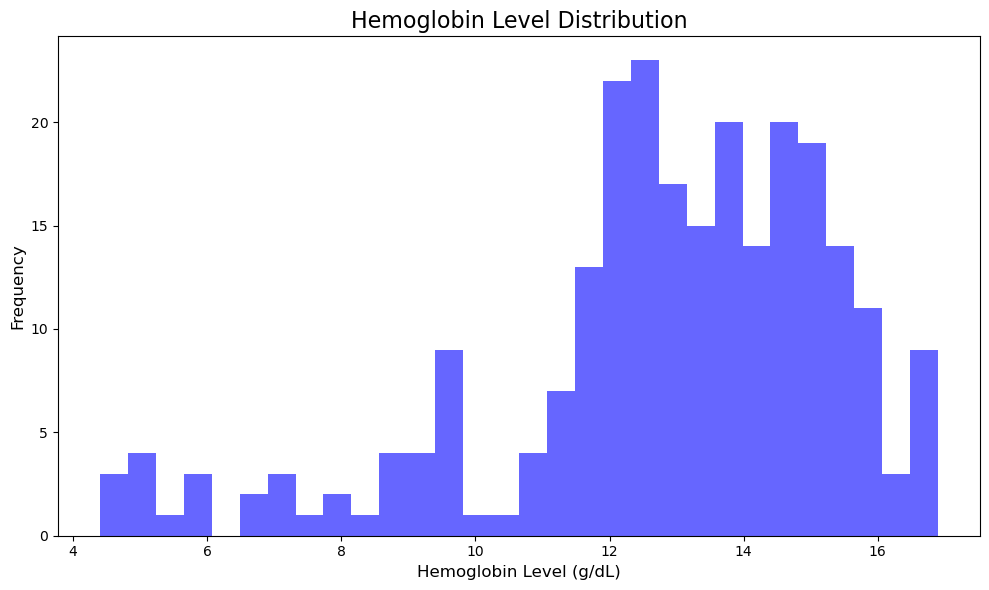

In [188]:
plot_hb_distribution(metadata, hb_column="HB_LEVEL_GperDeciL")

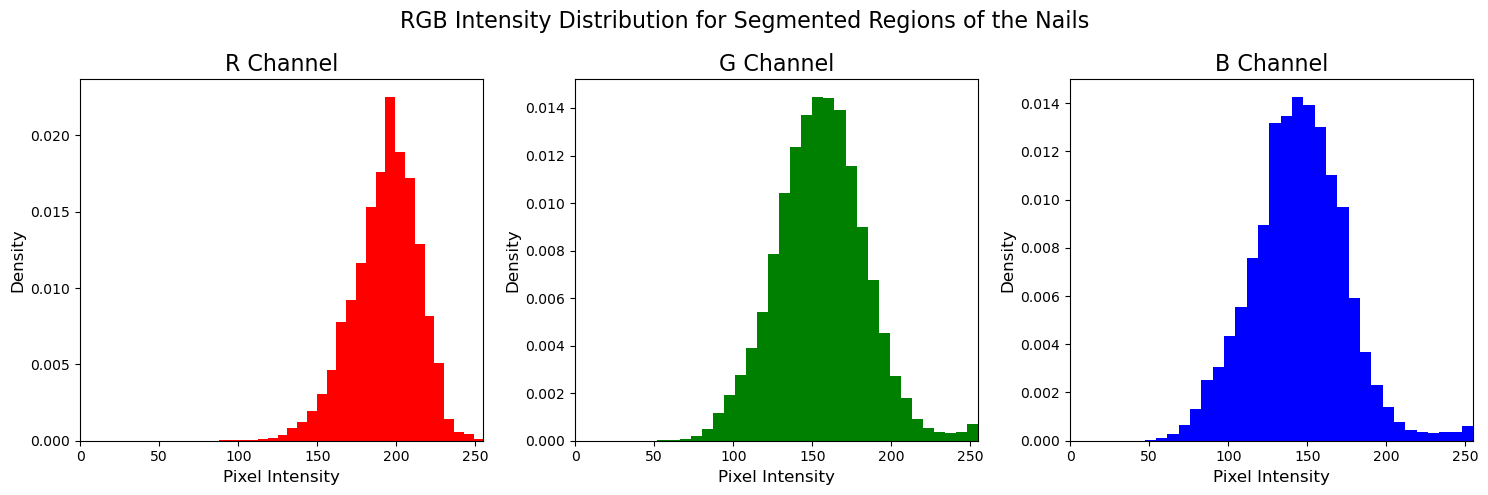

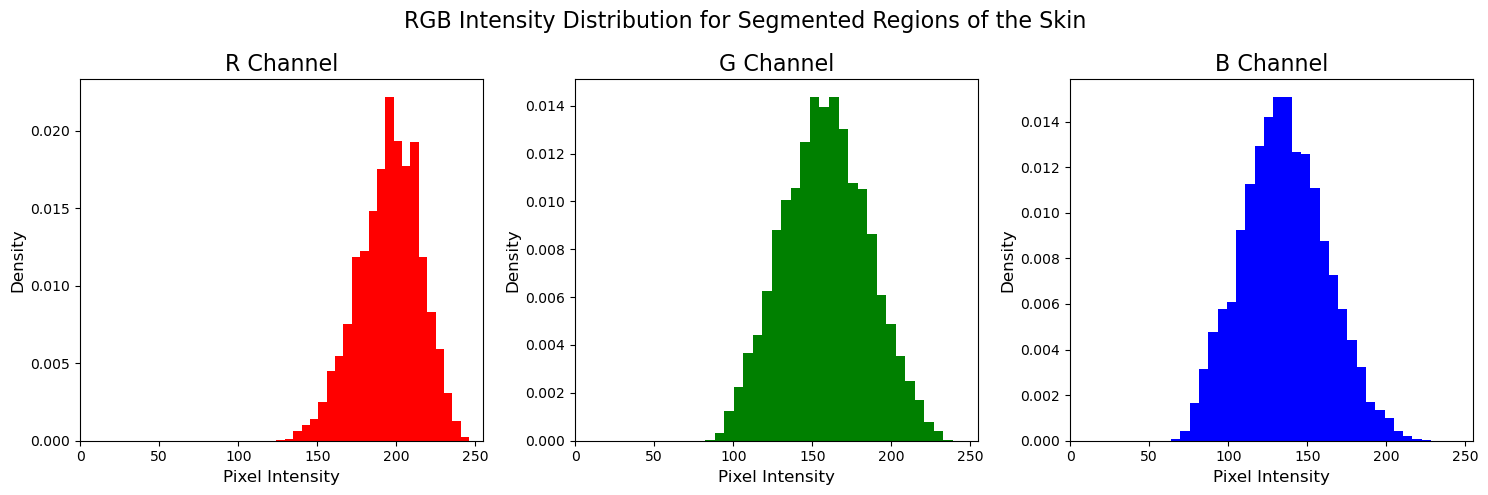

In [189]:
# Load metadata
metadata_df = load_metadata_with_bboxes(CSV_PATH)

# Load & crop nail regions
nail_crops = load_and_crop_images(DATA_DIR, metadata_df, region='NAIL_BOUNDING_BOXES')
skin_crops = load_and_crop_images(DATA_DIR, metadata_df, region='SKIN_BOUNDING_BOXES')

# Plot channel distributions for cropped nails
plot_rgb_channel_distributions(nail_crops, label='Segmented Regions of the Nails')
plot_rgb_channel_distributions(skin_crops, label='Segmented Regions of the Skin')

/var/folders/pd/pytqjfv51bddy0szx15zr3_c0000gn/T/ipykernel_1067/3923791149.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


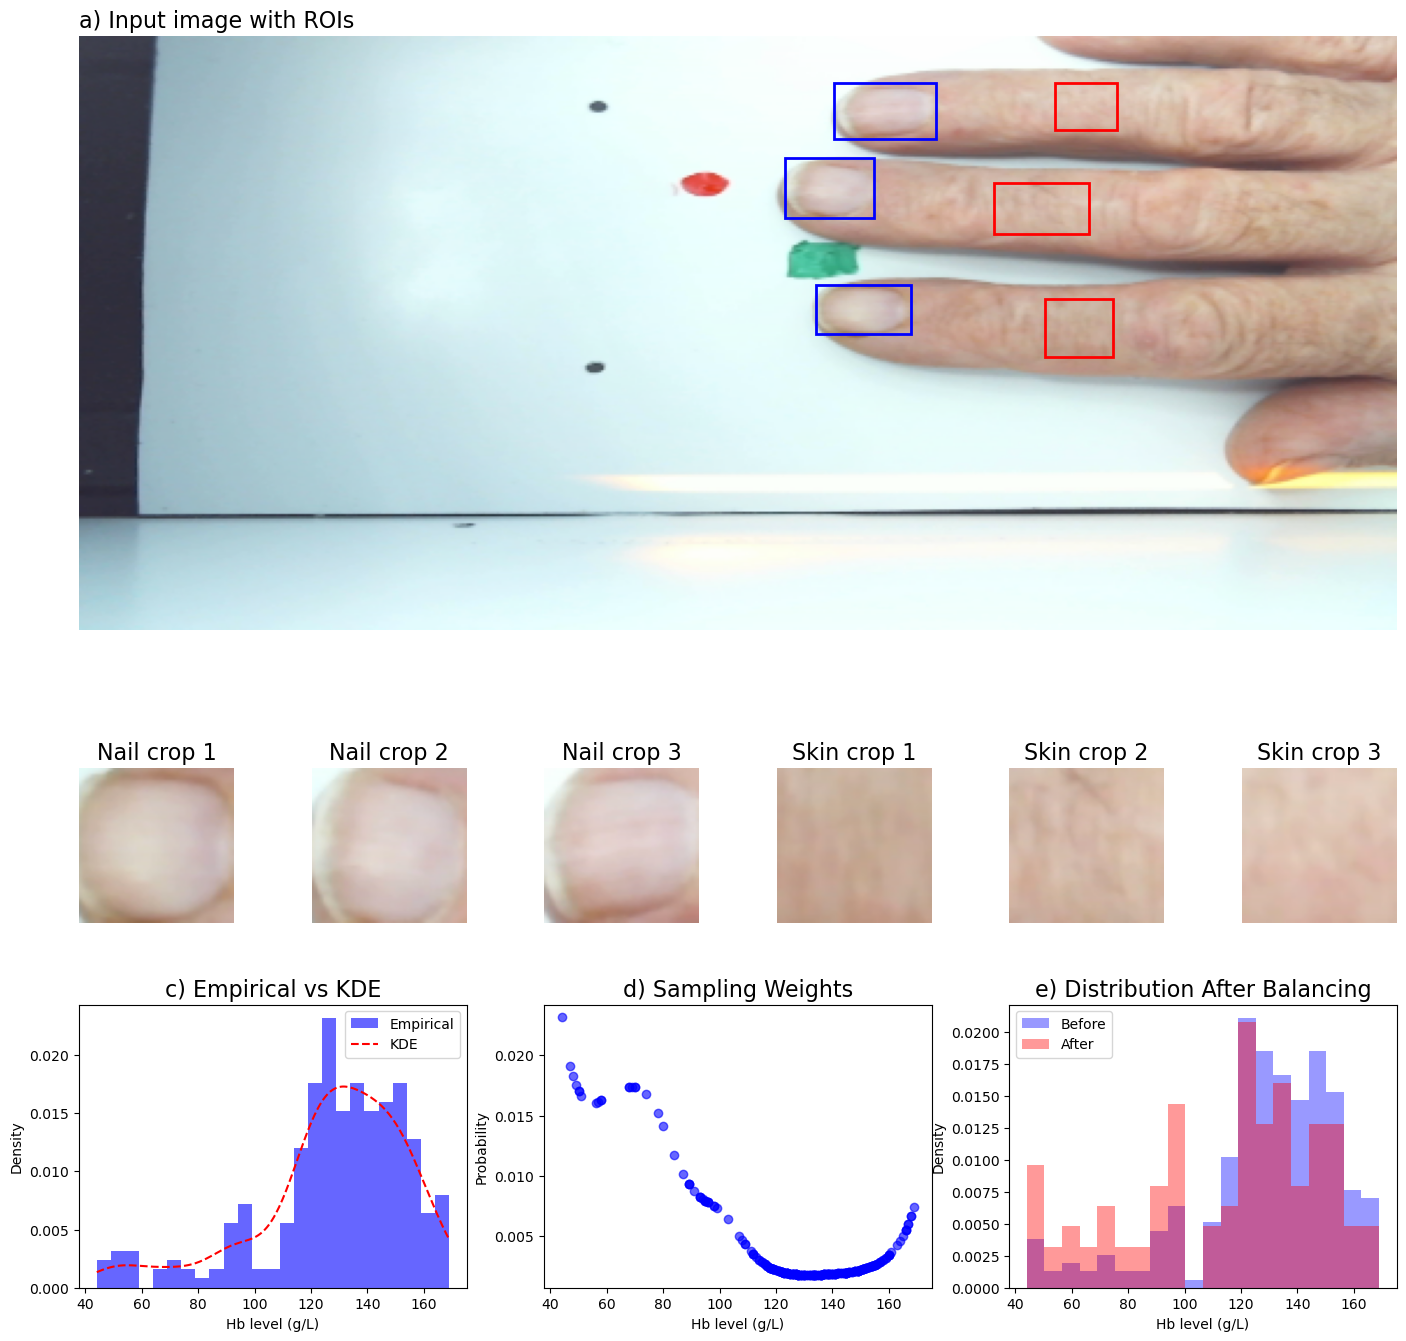

In [190]:
plot_preprocessing_and_balancing_from_metadata(
    metadata_csv=CSV_PATH,
    image_dir=DATA_DIR,
    row_index=0  # Index of patient/image you want to display
)

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_describe_metadata(csv_path='metadata.csv'):
    """
    Loads metadata, annotates with 'Remark' and 'Severity' based on Hb level,
    prints basic descriptive statistics, and plots frequency distribution.
    """
    df = pd.read_csv(csv_path)
    n = 30
    df["HB_LEVEL_GperDeciL"] = df["HB_LEVEL_GperL"] / 10

    # Define anemia class
    def remark_class(hb):
        return "Anemic" if hb < 120 else "Non-anemic"

    def severity_class(hb):
        if hb < 80:
            return "Severe"
        elif hb < 100:
            return "Moderate"
        elif hb < 120:
            return "Mild"
        else:
            return "Non-anemic"

    df["Remark"] = df["HB_LEVEL_GperL"].apply(remark_class)
    df["Severity"] = df["HB_LEVEL_GperL"].apply(severity_class)

    print(f"Random sample (n={n}) of metadata")
    display(df.sample(n))

    print("\nDescriptive Statistics:")
    display(df.describe())

    return df

def plot_remark_severity_distribution(df):
    """
    Plots frequency distributions for Hb levels categorized by severity and anemia remark,
    and prints class counts.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot by Remark
    remark_counts = df['Remark'].value_counts()
    for label in remark_counts.index:
        subset = df[df['Remark'] == label]
        axes[0].hist(subset['HB_LEVEL_GperDeciL'], bins=10, alpha=0.6, label=f"{label} (n={len(subset)})")
    axes[0].set_title("Hemoglobin Distribution by Remark")
    axes[0].set_xlabel("Hb Level (g/dL)")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    # Plot by Severity
    severity_order = ["Severe", "Moderate", "Mild", "Non-anemic"]
    severity_counts = df['Severity'].value_counts()
    for label in severity_order:
        if label in severity_counts:
            subset = df[df["Severity"] == label]
            axes[1].hist(subset['HB_LEVEL_GperDeciL'], bins=10, alpha=0.6, label=f"{label} (n={len(subset)})")
    axes[1].set_title("Hemoglobin Distribution by Severity")
    axes[1].set_xlabel("Hb Level (g/dL)")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\nClass Counts:")
    print("Remark:\n", remark_counts.to_string())
    print("\nSeverity:\n", severity_counts.loc[severity_order].fillna(0).astype(int).to_string())
    
def kde_balance_metadata(df, target_column="HB_LEVEL_GperL", n_samples=100, bandwidth=0.5, seed=42):
    """
    Applies KDE-based inverse sampling to balance Hb levels and anemia severity classes.
    Returns a new balanced dataframe.
    """
    np.random.seed(seed)
    hb_vals = df[target_column].values
    kde = gaussian_kde(hb_vals, bw_method=bandwidth / np.std(hb_vals))
    density = kde(hb_vals)
    sampling_probs = 1.0 / (density + 1e-6)
    sampling_probs /= sampling_probs.sum()

    sampled_indices = np.random.choice(df.index, size=n_samples, replace=False, p=sampling_probs)
    return df.loc[sampled_indices].reset_index(drop=True)

def kde_balance_by_severity(df, target_column="HB_LEVEL_GperL", severity_column="Severity",
                            n_per_class=30, bandwidth=0.5, seed=42):
    """
    Balances data across severity classes using KDE-weighted sampling within each class.
    """
    np.random.seed(seed)
    balanced_dfs = []

    for severity in df[severity_column].unique():
        group = df[df[severity_column] == severity]
        hb_vals = group[target_column].values

        if len(group) <= n_per_class:
            balanced_dfs.append(group)  # Take all if not enough samples
        else:
            kde = gaussian_kde(hb_vals, bw_method=bandwidth / np.std(hb_vals))
            density = kde(hb_vals)
            probs = 1.0 / (density + 1e-6)
            probs /= probs.sum()

            sampled = group.sample(n=n_per_class, weights=probs, replace=False, random_state=seed)
            balanced_dfs.append(sampled)

    return pd.concat(balanced_dfs).reset_index(drop=True)


In [211]:
df = load_and_describe_metadata(CSV_PATH)

Random sample (n=30) of metadata


,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES,HB_LEVEL_GperDeciL,Remark,Severity
142,197,665444f808712fd616e946a57c34990a,113.0,"[[284, 541, 333, 585], [193, 501, 245, 555], [...","[[287, 648, 343, 724], [195, 613, 252, 705], [...",11.3,Anemic,Mild
6,11,14b0293a34344cc4fba0fa39d5370c52,136.0,"[[262, 561, 317, 621], [173, 486, 233, 557], [...","[[290, 714, 341, 761], [191, 660, 241, 716], [...",13.6,Non-anemic,Non-anemic
97,131,e3981224ab5bcea1150ac871aa3d649b,131.0,"[[92, 541, 132, 595], [182, 485, 228, 543], [2...","[[84, 661, 133, 701], [185, 634, 229, 684], [2...",13.1,Non-anemic,Non-anemic
60,76,415a961921bff3678f2d06363da6ddbe,154.0,"[[74, 536, 125, 599], [145, 482, 196, 545], [2...","[[68, 671, 120, 722], [156, 628, 207, 697], [2...",15.4,Non-anemic,Non-anemic
112,153,7a506db2d2eea7bca089240b289851c7,145.0,"[[197, 528, 222, 576], [117, 495, 163, 546], [...","[[212, 636, 255, 680], [136, 632, 182, 669], [...",14.5,Non-anemic,Non-anemic
181,247,9092b2248bcb4c5ad65cc7f670c9f0a9,151.0,"[[101, 568, 154, 629], [176, 531, 233, 590], [...","[[93, 712, 156, 758], [189, 668, 244, 726], [2...",15.1,Non-anemic,Non-anemic
197,265,906e7396b2ed0ebdb5a592bc76c0935f,116.0,"[[222, 589, 280, 646], [137, 531, 200, 595], [...","[[256, 719, 319, 770], [155, 675, 225, 743], [...",11.6,Anemic,Mild
184,250,9092b2248bcb4c5ad65cc7f670c9f0a9,126.0,"[[241, 544, 289, 604], [170, 507, 219, 569], [...","[[264, 655, 317, 713], [188, 628, 233, 703], [...",12.6,Non-anemic,Non-anemic
9,15,7239c14d8ddc5b692aeae707b0f99ecc,56.0,"[[218, 513, 261, 580], [142, 465, 191, 539], [...","[[237, 657, 282, 678], [151, 626, 194, 673], [...",5.6,Anemic,Severe
104,141,e3981224ab5bcea1150ac871aa3d649b,68.0,"[[293, 545, 340, 594], [199, 496, 257, 547], [...","[[298, 669, 344, 727], [204, 644, 252, 686], [...",6.8,Anemic,Severe



Descriptive Statistics:


,PATIENT_ID,HB_LEVEL_GperL,HB_LEVEL_GperDeciL
count,250.00000,250.000000,250.000000
mean,170.32400,127.592000,12.759200
std,100.07296,26.709533,2.670953
min,1.00000,44.000000,4.400000
25%,79.50000,118.250000,11.825000
50%,175.50000,131.500000,13.150000
75%,252.75000,146.000000,14.600000
max,342.00000,169.000000,16.900000


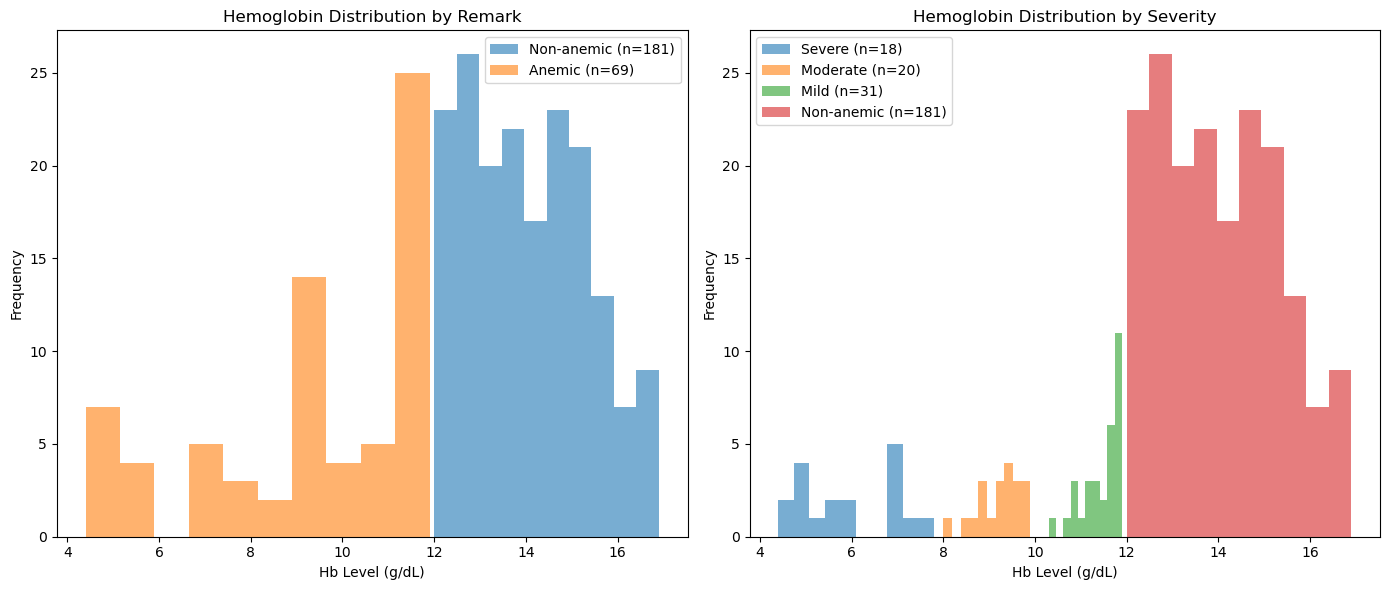


Class Counts:
Remark:
 Remark
Non-anemic    181
Anemic         69

Severity:
 Severity
Severe         18
Moderate       20
Mild           31
Non-anemic    181


In [212]:
plot_remark_severity_distribution(df)

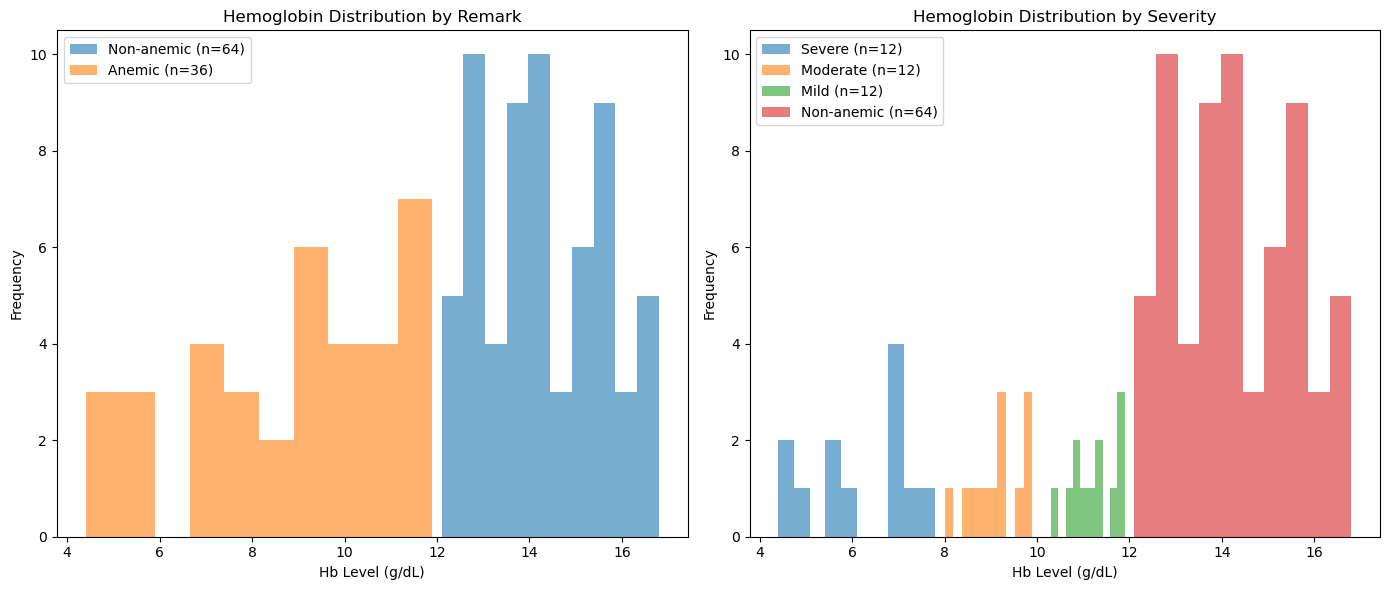


Class Counts:
Remark:
 Remark
Non-anemic    64
Anemic        36

Severity:
 Severity
Severe        12
Moderate      12
Mild          12
Non-anemic    64


In [213]:
df_balanced = kde_balance_metadata(df, n_samples=100)
plot_remark_severity_distribution(df_balanced)

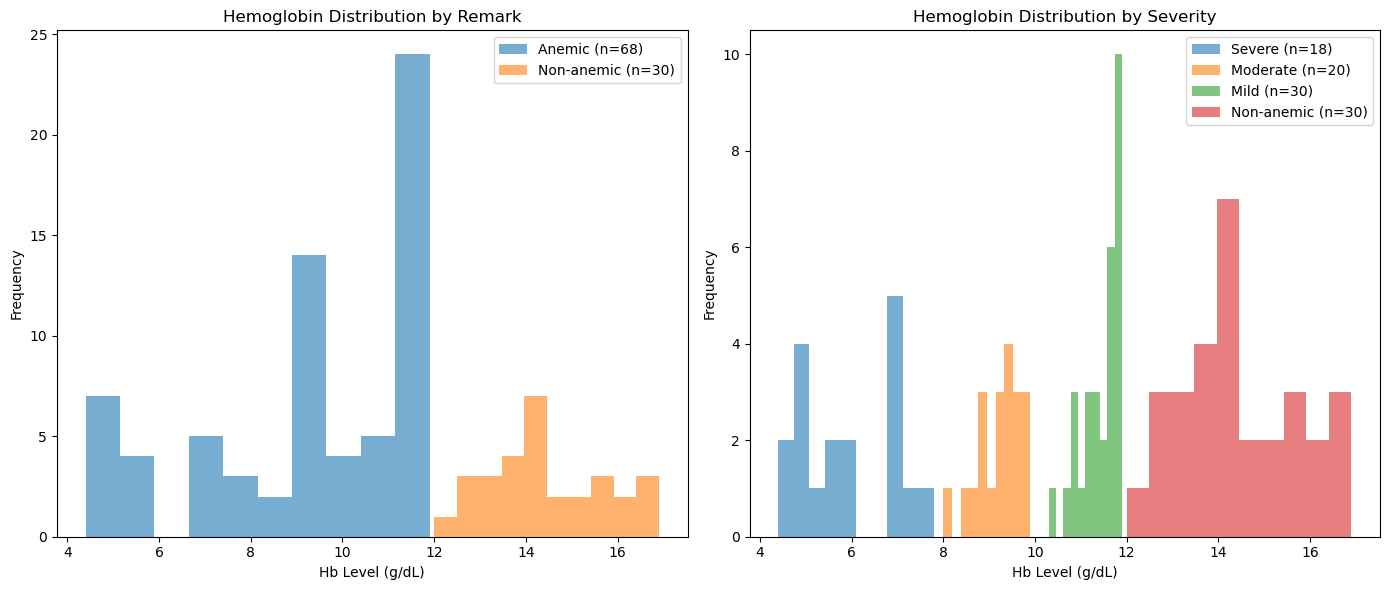


Class Counts:
Remark:
 Remark
Anemic        68
Non-anemic    30

Severity:
 Severity
Severe        18
Moderate      20
Mild          30
Non-anemic    30


In [214]:
df_balanced_severity = kde_balance_by_severity(df, n_per_class=30)

# Review new class distributions
plot_remark_severity_distribution(df_balanced_severity)